# 🧭 Estrutura reestruturada do projeto

## 1️⃣ Problema de pesquisa

Pergunta central:

> O crescimento populacional pressiona os preços de aluguel nas cidades brasileiras quando a oferta imobiliária não acompanha a demanda?

Subperguntas:

* qual o efeito **de curto prazo**?
* qual o efeito **de longo prazo**?
* fatores financeiros (juros) amplificam esse efeito?

Hipótese principal:

[
\Delta População ↑ \Rightarrow Aluguel ↑
]

quando a oferta imobiliária é rígida.

---

# 2️⃣ Coleta de dados

Ideal incluir **três blocos de variáveis**.

### Demanda por moradia

* população
* crescimento populacional
* renda
* emprego
* atividade econômica

### Oferta imobiliária

* estoque de imóveis
* novos alvarás
* construção civil
* custo da construção

### Financeiro

* juros
* crédito imobiliário

Exemplos no Brasil:

* população → IBGE
* aluguel → FipeZap
* atividade → IBC-Br
* construção → CUB ou INCC

---

# 3️⃣ Construção do dataset

Painel:

[
cidade_i , tempo_t
]

Estrutura:

| cidade | ano | aluguel | população | renda | construção | juros |
| ------ | --- | ------- | --------- | ----- | ---------- | ----- |

Painel balanceado se possível.

---

# 4️⃣ Transformações

Separar **curto prazo e longo prazo**.

### longo prazo

variáveis em **log nível**

[
log(aluguel)
]

[
log(população)
]

Isso captura **elasticidade estrutural**.

---

### curto prazo

diferenças:

[
\Delta log(aluguel)
]

[
\Delta log(população)
]

Isso captura **choques temporários**.

---

# 5️⃣ Análise exploratória

Aqui você pode mostrar:

* crescimento populacional
* evolução dos aluguéis
* dispersão entre cidades

Gráficos úteis:

* aluguel vs população
* crescimento populacional vs inflação de aluguel

Isso ajuda a **visualizar a teoria antes da econometria**.

---

# 6️⃣ VIF

Testar multicolinearidade.

Principalmente entre:

* renda
* atividade econômica
* emprego

---

# 7️⃣ Stepwise / AIC

Selecionar variáveis mais relevantes para:

* demanda
* oferta
* financeiro

Mas sempre respeitando **teoria econômica**.

Não deixar algoritmo remover variável essencial.

---

# 8️⃣ Modelos econométricos de painel

Aqui você separa **três modelos**.

---

## Modelo 1 — longo prazo

$$
log(aluguel_{it}) =
\alpha_i +
\beta_1 log(pop_{it}) +
\beta_2 renda_{it} +
\beta_3 oferta_{it}
$$

Aqui você quer provar:

$$
\beta_1 > 0
$$

---

## Modelo 2 — curto prazo

$$
\Delta log(aluguel_{it}) =
\beta_1 \Delta log(pop_{it}) +
\beta_2 juros_t +
\beta_3 atividade_t
$$

Aqui juros provavelmente aparecem mais.

---

## Modelo 3 — interação demanda/oferta

$$
log(aluguel) =
\beta_1 pop +
\beta_2 construção +
\beta_3 pop \times construção
$$

Isso mostra:

**oferta imobiliária reduz pressão populacional.**

---

# 9️⃣ XGBoost

Treinar modelo para prever:

$$
\Delta aluguel
$$

Variáveis:

* população
* renda
* atividade
* juros
* construção

Objetivo:

avaliar **importância relativa das variáveis**.

---

# 🔟 Machine learning com painel

Possibilidades:

* panel random forest
* gradient boosting com efeitos fixos

Ou incluir:

```
cidade como variável categórica
```

---

# 1️⃣1️⃣ SHAP

Interpretar ML.

Você pode mostrar:

* impacto da população
* impacto da atividade econômica
* impacto de juros

Gráfico típico:

```
SHAP importance
```

Isso ajuda a validar os resultados econométricos.

---

# 1️⃣2️⃣ Interpretação econômica

Aqui você junta tudo:

Resultados possíveis:

* população afeta aluguel **no longo prazo**
* juros afetam aluguel **no curto prazo**
* oferta imobiliária modera esse efeito

Isso gera um argumento muito sólido.

---

# 1️⃣3️⃣ Conclusão e implicações de política

Aqui entram suas ideias.

### Política 1 — incentivo à construção

Se população cresce mais que oferta:

```
escassez de moradia
↓
aluguel sobe
```

Políticas possíveis:

* incentivos fiscais
* simplificação regulatória
* expansão urbana

---

### Política 2 — crédito imobiliário

Se juros altos pressionam aluguel:

políticas possíveis:

* subsídio habitacional
* crédito imobiliário regional

Você pode discutir algo como:

**“Selic regional” ou políticas de crédito local.**

---

# 🧠 Narrativa final do TCC

Ficaria assim:

1️⃣ população aumenta demanda por moradia
2️⃣ oferta reage lentamente
3️⃣ preços de aluguel sobem
4️⃣ juros amplificam esse efeito
5️⃣ políticas públicas devem expandir oferta imobiliária

---

# ⭐ Resultado ideal do estudo

Se tudo funcionar bem, você mostrará:

* **população → aluguel (longo prazo)**
* **juros → aluguel (curto prazo)**
* **oferta imobiliária reduz pressão**

Isso vira um **argumento econômico completo**.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pprint

from src.pre_process.stepwise import stepwise_selection
from mlxtend.feature_selection import SequentialFeatureSelector

from xgboost import XGBRegressor

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from linearmodels.panel import PanelOLS
from linearmodels.panel import RandomEffects
from linearmodels.panel import compare
import seaborn as sns

import optuna

# =========================
# 1. CARREGAMENTO DOS DADOS
# =========================
pop = pd.read_csv("../data/processed/pop_municipal_corrigido_anual_ibge.csv", sep=";")
aluguel = pd.read_csv("../data/processed/aluguel_fipezap.csv")
macro = pd.read_csv("../data/processed/macro_brasil_anual_2009_2023.csv")
caged = pd.read_csv("../data/processed/caged_2008_2022_por_cidade.csv", sep=";")
obras = pd.read_csv("../data/raw/m2_construido_cidade_ano.csv", sep=",")
obras = obras.rename(columns={
    "id_municipio": "codigo_ibge"
})

# =========================
# 2. TRATAMENTO - POPULAÇÃO
# =========================
pop = pop.sort_values(["codigo_ibge", "ano"])

# usar diretamente as variáveis já prontas
pop = pop.rename(columns={
    "pop_corrigida": "populacao",
    "log_pop_corr": "log_pop",
    "dlog_pop_corr": "dlog_pop"
})

# =========================
# 3. TRATAMENTO - OBRAS (OFERTA)
# =========================
obras = obras.rename(columns={
    "id_municipio": "codigo_ibge"
})

obras = obras.sort_values(["codigo_ibge", "ano"])

# log da área construída
obras["log_area"] = np.log(obras["area_total_construida"])

# crescimento da construção (proxy de oferta)
obras["dlog_area"] = (
    obras.groupby("codigo_ibge")["log_area"]
    .diff()
)


# =========================
# 4. TRATAMENTO - CAGED (DEMANDA)
# =========================
caged = caged.rename(columns={
    "id_municipio": "codigo_ibge",
    "saldo_anual": "caged"
})

caged["codigo_ibge"] = caged["codigo_ibge"].astype(int)

caged = caged.sort_values(["codigo_ibge", "ano"])


# =========================
# 5. MERGES
# =========================
df = pop.merge(
    aluguel,
    on=["codigo_ibge", "ano"],
    how="inner"
)

df = df.merge(
    macro,
    on="ano",
    how="left"
)

df = df.merge(
    caged,
    on=["codigo_ibge", "ano"],
    how="left"
)

df = df.merge(
    obras[["codigo_ibge", "ano", "dlog_area"]],
    on=["codigo_ibge", "ano"],
    how="left"
)


# =========================
# 6. FEATURE ENGINEERING
# =========================

# CAGED per capita (demanda)
df["caged_per_capita"] = df["caged"] / df["populacao"]

# log do CAGED (opcional)
df["log_caged"] = np.log(df["caged"].abs() + 1)


# =========================
# 7. SELEÇÃO FINAL
# =========================
df_final = df[[
    "codigo_ibge",
    "cidade",
    "ano",
    "populacao",
    "log_pop",
    "dlog_pop",
    "dlog_aluguel",
    "caged_per_capita",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1",
    "dlog_area"
]]

df_final = df_final.sort_values(["codigo_ibge", "ano"])

df_final["dlog_pop_lag1"] = (
    df_final.groupby("codigo_ibge")["dlog_pop"].shift(1)
)
df_final["dlog_area_lag1"] = df_final.groupby("codigo_ibge")["dlog_area"].shift(1)


df_model = df_final.dropna()


# remover apenas observações incompletas
df_final = df_final.dropna()


# =========================
# 8. AJUSTES FINAIS
# =========================
df_final = df_final.rename(columns={
    "nome_municipio": "cidade"
})


# =========================
# 9. EXPORTAÇÃO
# =========================
df_final.to_csv(
    "../data/processed/dataset_final_aluguel.csv",
    index=False
)

/home/gustavo/Área de Trabalho/tcc-migracao-e-inflacao/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X = df_model[[
    "dlog_pop_lag1",
    "caged_per_capita",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1",
    "dlog_area"
]]

X = sm.add_constant(X)
y = df_model["dlog_aluguel"]

model = sm.OLS(y, X).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           dlog_aluguel   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.566
Method:                 Least Squares   F-statistic:                     20.54
Date:                Thu, 14 May 2026   Prob (F-statistic):           3.45e-16
Time:                        02:44:12   Log-Likelihood:                 214.31
No. Observations:                 121   AIC:                            -414.6
Df Residuals:                     114   BIC:                            -395.1
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0414      0.012  

In [3]:
X = df_model[[
    "dlog_pop_lag1",
    "caged_per_capita",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1",
    "dlog_area_lag1"
]]

X = sm.add_constant(X)
y = df_model["dlog_aluguel"]

model = sm.OLS(y, X).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           dlog_aluguel   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.571
Method:                 Least Squares   F-statistic:                     18.25
Date:                Thu, 14 May 2026   Prob (F-statistic):           9.23e-15
Time:                        02:44:12   Log-Likelihood:                 215.00
No. Observations:                 121   AIC:                            -416.0
Df Residuals:                     114   BIC:                            -396.4
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0410      0.012  

In [4]:

X = df_model[[
    "dlog_pop_lag1",
    "caged_per_capita",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1",
    "dlog_area_lag1"
]]

X = sm.add_constant(X)
y = df_model["dlog_aluguel"]

model = sm.OLS(y, X).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           dlog_aluguel   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.571
Method:                 Least Squares   F-statistic:                     18.25
Date:                Thu, 14 May 2026   Prob (F-statistic):           9.23e-15
Time:                        02:44:12   Log-Likelihood:                 215.00
No. Observations:                 121   AIC:                            -416.0
Df Residuals:                     114   BIC:                            -396.4
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0410      0.012  

$$
dlog_aluguel_{it} = \beta_0 + \beta_1 dlog_pop_{i,t-1} + \beta_2 caged_pc_{it} + \beta_3 selic_t + \beta_4 d_ic_t + \beta_5 dlog_incc_{t-1} + \beta_6 dlog_area_{i,t-1} + \varepsilon_{it}
$$

📊 Justificativa

O modelo final adota a variável de oferta com uma defasagem de um período, por apresentar melhor ajuste estatístico (maior R² e menor AIC), além de maior aderência teórica, dado que a oferta imobiliária impacta o mercado de aluguel com defasagem temporal. Modelos com defasagem contemporânea ou maior defasagem (dois períodos) apresentaram desempenho inferior.

Modelo final:


In [5]:
X = df_model[[
    "dlog_pop_lag1",
    "caged_per_capita",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1",
    "dlog_area_lag1"
]]

X = sm.add_constant(X)
y = df_model["dlog_aluguel"]

model = sm.OLS(y, X).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           dlog_aluguel   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.571
Method:                 Least Squares   F-statistic:                     18.25
Date:                Thu, 14 May 2026   Prob (F-statistic):           9.23e-15
Time:                        02:44:12   Log-Likelihood:                 215.00
No. Observations:                 121   AIC:                            -416.0
Df Residuals:                     114   BIC:                            -396.4
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0410      0.012  

In [6]:
# modelo final econométrico
X = df_model[[
    "dlog_pop_lag1",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1"
]]

X = sm.add_constant(X)
y = df_model["dlog_aluguel"]

model_sm = sm.OLS(y, X).fit(cov_type="HC3")

# resíduos
residuos = model_sm.resid
X_ols = model_sm.model.exog

# =========================
# TESTES
# =========================

# Heterocedasticidade
bp = het_breuschpagan(residuos, X_ols)
print("Breusch-Pagan:", bp)

# Normalidade
jb = stats.jarque_bera(residuos)
print("Jarque-Bera:", jb)

print(model_sm.summary())

Breusch-Pagan: (np.float64(7.916071691196497), np.float64(0.09470142966156846), np.float64(2.030050445522302), np.float64(0.09471996178130332))
Jarque-Bera: SignificanceResult(statistic=np.float64(0.04467101871842054), pvalue=np.float64(0.9779120813491917))
                            OLS Regression Results                            
Dep. Variable:           dlog_aluguel   R-squared:                       0.582
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                     27.85
Date:                Thu, 14 May 2026   Prob (F-statistic):           3.26e-16
Time:                        02:44:12   Log-Likelihood:                 213.49
No. Observations:                 121   AIC:                            -417.0
Df Residuals:                     116   BIC:                            -403.0
Df Model:                           4                                         
Covariance Type:               

## VIF
O VIF mede se uma variável explicativa está altamente correlacionada com as outras.

In [7]:
# mesmas variáveis do modelo final (SEM o y)
X = df_model[[
    "dlog_pop_lag1",
    "caged_per_capita",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1",
    "dlog_area_lag1"
]]

# adicionar constante
X = sm.add_constant(X)

# calcular VIF
vif = pd.DataFrame()
vif["variavel"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

           variavel        VIF
0             const  11.381212
1     dlog_pop_lag1   1.099045
2  caged_per_capita   2.039269
3       selic_media   5.874540
4           d_ic_br   3.564689
5    dlog_incc_lag1   5.699111
6    dlog_area_lag1   1.014658



#  **2. Interpretação variável por variável**

| Variável         | VIF  | Diagnóstico |
| ---------------- | ---- | ----------- |
| dlog_pop_lag1    | 1.09 | ✅ Excelente |
| caged_per_capita | 2.04 | ✅ Muito bom |
| selic_media      | 5.87 | ⚠️ Moderado |
| d_ic_br          | 3.56 | ✅ Ok        |
| dlog_incc_lag1   | 5.70 | ⚠️ Moderado |
| dlog_area_lag1   | 1.01 | ✅ Excelente |

---

##  Multicolinearidade moderada:

* `selic_media` (~5.87)
* `dlog_incc_lag1` (~5.70)


### Diagnóstico de Multicolinearidade

> O teste de multicolinearidade foi realizado por meio do Fator de Inflação da Variância (VIF). Os resultados indicam que a maioria das variáveis apresenta valores baixos de VIF, sugerindo ausência de multicolinearidade relevante.
>
> As variáveis macroeconômicas, em especial a taxa SELIC e o custo da construção (INCC), apresentaram valores moderados de VIF, próximos de 6, o que é esperado devido à correlação entre indicadores econômicos agregados.
>
> No entanto, tais valores permanecem abaixo dos limites críticos usualmente adotados na literatura, não comprometendo a estabilidade das estimativas nem a interpretação dos coeficientes.

> O modelo apresenta níveis aceitáveis de multicolinearidade, sem evidências de problemas que comprometam a validade dos resultados.


## Stepwise (AIC)
Método automático que testa combinações de variáveis e escolhe o modelo com menor AIC.

In [8]:
X = df_model[[
    "dlog_pop_lag1",
    "caged_per_capita",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1",
    "dlog_area_lag1"
]]

y = df_model["dlog_aluguel"]

best_vars = stepwise_selection(X, y)
print("Variáveis selecionadas:", best_vars)

Variáveis selecionadas: ['dlog_pop_lag1', 'selic_media', 'd_ic_br', 'dlog_incc_lag1']


## MSE

O SequentialFeatureSelector (SFS) é um algoritmo de seleção de características do tipo wrapper que adiciona ou remove colunas de forma iterativa para otimizar o desempenho de um modelo. Quando utilizado em problemas de regressão, o Erro Quadrático Médio (MSE) é uma das métricas mais comuns para avaliar essas combinações de características

In [9]:
X = df_model[[
    "dlog_pop_lag1",
    "caged_per_capita",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1",
    "dlog_area_lag1"
]]

y = df_model["dlog_aluguel"]

model = LinearRegression()

sfs = SequentialFeatureSelector(
    model,
    k_features='best',
    forward=False,  # backward (igual seu caso)
    scoring='neg_mean_squared_error',
    cv=0
)

sfs = sfs.fit(X, y)

print("Variáveis selecionadas:", list(sfs.k_feature_names_))

Variáveis selecionadas: ['dlog_pop_lag1', 'caged_per_capita', 'selic_media', 'd_ic_br', 'dlog_incc_lag1', 'dlog_area_lag1']


### 📊 AIC (econometria)

Selecionou:

* `dlog_pop_lag1`
* `selic_media`
* `d_ic_br`
* `dlog_incc_lag1`

👉 Modelo **mais enxuto e interpretável**

---

### 🤖 MSE (machine learning)

Selecionou:

* Todas as variáveis

👉 Modelo **mais preditivo**

---

## 🏗️ **3. Estrutura ideal do seu TCC**

### 🔹 **Modelo 1 — Econométrico (PRINCIPAL)**

👉 Use o modelo AIC:

```python
[
    "dlog_pop_lag1",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1"
]
```

---

#### 💡 Interpretação:

Esse modelo responde sua pergunta:

> **Como a migração (população) impacta o aluguel?**

✔️ Limpo
✔️ Interpretável
✔️ Coerente teoricamente

---

### 🔹 **Modelo 2 — Completo (teórico)**

👉 Seu modelo original:

```python
[
    "dlog_pop_lag1",
    "caged_per_capita",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1",
    "dlog_area_lag1"
]
```

👉 Serve para:

* mostrar robustez
* justificar variáveis

---

### 🔹 **Modelo 3 — Machine Learning**

👉 Modelo MSE (todas variáveis)

👉 Serve para:

* previsão
* comparação com econometria

---

## 🔥 **4. O insight MAIS FORTE do seu TCC**

> Modelos econométricos e de machine learning apresentam critérios distintos de seleção de variáveis, refletindo o trade-off entre interpretabilidade e capacidade preditiva.

---

## 📌 **5. Resposta direta à sua pergunta de pesquisa**

👉 Sua pergunta:

> Como a migração impacta o aluguel?

---

### 💥 Resposta baseada no modelo AIC:

> O crescimento populacional (proxy de migração) apresenta efeito positivo e estatisticamente significativo sobre o crescimento dos aluguéis, mesmo após o controle por variáveis macroeconômicas.

---

#### 📄 Seleção de Variáveis

> Foram utilizados dois critérios de seleção de variáveis. O critério de informação de Akaike (AIC), tradicional na literatura econométrica, resultou em um modelo mais parcimonioso, mantendo apenas variáveis estatisticamente relevantes.
>
> Por outro lado, um procedimento baseado em erro quadrático médio (MSE), associado a técnicas de machine learning, indicou a inclusão de todas as variáveis disponíveis, priorizando a capacidade preditiva do modelo.
>
> Essa diferença evidencia o trade-off entre interpretabilidade e desempenho preditivo, sendo ambos os modelos utilizados de forma complementar na análise.

---

👉 como será usado:

* **AIC → modelo principal (causalidade)**
* **MSE → modelo complementar (previsão)**


# Painel


# 🧱 **3. Modelo que você vai estimar**

## 📌 Especificação:

$$
dlog\_aluguel_{it} =
\beta_1 dlog\_pop_{i,t-1} +
\beta_2 selic_t +
\beta_3 d\_ic\_br_t +
\beta_4 dlog\_incc_{t-1} +
\alpha_i + \varepsilon_{it}
$$

Onde:

$$ \alpha_i $$ é o efeito fixo da cidade

In [10]:
# dados em painel
df_panel = df_model.set_index(["codigo_ibge", "ano"])

X = df_panel[[
    "dlog_pop_lag1",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1"
]]

y = df_panel["dlog_aluguel"]

# adicionar constante
X = sm.add_constant(X)

# modelo RE
model_re = RandomEffects(y, X)
result_re = model_re.fit(cov_type="robust")

print(result_re.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:           dlog_aluguel   R-squared:                        0.6058
Estimator:              RandomEffects   R-squared (Between):              0.5411
No. Observations:                 121   R-squared (Within):               0.5986
Date:                Thu, May 14 2026   R-squared (Overall):              0.5744
Time:                        02:44:12   Log-likelihood                    224.93
Cov. Estimator:                Robust                                           
                                        F-statistic:                      44.572
Entities:                          21   P-value                           0.0000
Avg Obs:                       5.7619   Distribution:                   F(4,116)
Min Obs:                       3.0000                                           
Max Obs:                       11.000   F-statistic (robust):             31.754
                            

In [11]:
# definir índice de painel
df_panel = df_model.set_index(["codigo_ibge", "ano"])

# variáveis
X = df_panel[[
    "dlog_pop_lag1",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1"
]]

y = df_panel["dlog_aluguel"]

# adicionar constante
X = sm.add_constant(X)

# modelo com efeitos fixos (cidade)
model_fe = PanelOLS(y, X, entity_effects=True)

result_fe = model_fe.fit(cov_type="robust")

print(result_fe.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:           dlog_aluguel   R-squared:                        0.6162
Estimator:                   PanelOLS   R-squared (Between):              0.2513
No. Observations:                 121   R-squared (Within):               0.6162
Date:                Thu, May 14 2026   R-squared (Overall):              0.5139
Time:                        02:44:12   Log-likelihood                    239.83
Cov. Estimator:                Robust                                           
                                        F-statistic:                      38.530
Entities:                          21   P-value                           0.0000
Avg Obs:                       5.7619   Distribution:                    F(4,96)
Min Obs:                       3.0000                                           
Max Obs:                       11.000   F-statistic (robust):             30.917
                            

In [12]:
print(compare({
    "FE": result_fe,
    "RE": result_re
}))

                     Model Comparison                     
                                      FE                RE
----------------------------------------------------------
Dep. Variable               dlog_aluguel      dlog_aluguel
Estimator                       PanelOLS     RandomEffects
No. Observations                     121               121
Cov. Est.                         Robust            Robust
R-squared                         0.6162            0.6058
R-Squared (Within)                0.6162            0.5986
R-Squared (Between)               0.2513            0.5411
R-Squared (Overall)               0.5139            0.5744
F-statistic                       38.530            44.572
P-value (F-stat)                  0.0000            0.0000
=====================     ==============   ===============
const                             0.0364            0.0405
                                (3.6255)          (4.0234)
dlog_pop_lag1                    -0.4366            0.64

Apesar da similaridade nos indicadores de ajuste, como o R² e a estatística F, os modelos de efeitos fixos e aleatórios apresentam diferenças relevantes nos coeficientes estimados, especialmente para a variável de crescimento populacional.

Isso evidencia que a escolha do modelo não deve ser baseada apenas na capacidade preditiva, mas também na consistência dos estimadores, uma vez que o modelo de efeitos aleatórios pode estar sujeito a viés caso a hipótese de independência entre efeitos individuais e variáveis explicativas não seja satisfeita.

Os resultados indicam que, embora exista uma associação positiva entre crescimento populacional e aluguéis na análise agregada, essa relação não se mantém quando se controlam características fixas dos municípios.

Isso sugere que o impacto da população sobre os preços de aluguel pode estar mais associado a diferenças estruturais entre cidades do que a variações ao longo do tempo dentro de cada município.

In [13]:
df_ext = df_model.copy()

df_ext["dlog_pop_lag3"] = (
    df_ext.groupby("codigo_ibge")["dlog_pop"].shift(3)
)

df_ext["dlog_pop_3y"] = (
    df_ext.groupby("codigo_ibge")["log_pop"].diff(3)
)
df_ext = df_ext.dropna()


In [14]:
X = df_ext[[
    "dlog_pop_lag3",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1"
]]

X = sm.add_constant(X)
y = df_ext["dlog_aluguel"]

model = sm.OLS(y, X).fit(cov_type="HC3")
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           dlog_aluguel   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.575
Method:                 Least Squares   F-statistic:                     12.03
Date:                Thu, 14 May 2026   Prob (F-statistic):           5.02e-07
Time:                        02:44:12   Log-Likelihood:                 102.17
No. Observations:                  58   AIC:                            -194.3
Df Residuals:                      53   BIC:                            -184.0
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0398      0.018      2.

In [15]:
X = df_ext[[
    "dlog_pop_3y",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1"
]]

X = sm.add_constant(X)
y = df_ext["dlog_aluguel"]

model = sm.OLS(y, X).fit(cov_type="HC3")
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           dlog_aluguel   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.586
Method:                 Least Squares   F-statistic:                     11.87
Date:                Thu, 14 May 2026   Prob (F-statistic):           5.90e-07
Time:                        02:44:12   Log-Likelihood:                 102.92
No. Observations:                  58   AIC:                            -195.8
Df Residuals:                      53   BIC:                            -185.5
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0477      0.019      2.

In [16]:
df_fe = df_ext.copy()
df_fe = df_fe.set_index(["codigo_ibge", "ano"])
df_fe = df_fe.dropna()

In [17]:
X = df_fe[[
    "dlog_pop_3y",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1"
]]

y = df_fe["dlog_aluguel"]

model_fe_3y = PanelOLS(y, X, entity_effects=True)
result_fe_3y = model_fe_3y.fit(cov_type="robust")

print(result_fe_3y.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:           dlog_aluguel   R-squared:                        0.6292
Estimator:                   PanelOLS   R-squared (Between):              0.3757
No. Observations:                  58   R-squared (Within):               0.6292
Date:                Thu, May 14 2026   R-squared (Overall):              0.4445
Time:                        02:44:12   Log-likelihood                    119.31
Cov. Estimator:                Robust                                           
                                        F-statistic:                      16.546
Entities:                          15   P-value                           0.0000
Avg Obs:                       3.8667   Distribution:                    F(4,39)
Min Obs:                       2.0000                                           
Max Obs:                       8.0000   F-statistic (robust):             14.076
                            

No modelo pooled OLS, um aumento de 1% na população está associado a um aumento aproximado de 0,9% nos preços de aluguel. No entanto, essa relação não se mantém nos modelos de efeitos fixos, nos quais o coeficiente não é estatisticamente significativo.

Isso sugere que a associação observada no modelo pooled pode refletir, em grande parte, diferenças estruturais entre municípios, e não necessariamente um efeito causal decorrente de variações populacionais ao longo do tempo.

Além disso, os intervalos de confiança estimados indicam que o impacto da população sobre os aluguéis no curto prazo é incerto e pode variar amplamente, não sendo possível identificar um efeito médio robusto.


relação entre população e aluguel aparece quando comparamos cidades diferentes, mas não quando analisamos a evolução dentro da mesma cidade ao longo do tempo.

## XBOOST

In [18]:
# dados
X = df_model[[
    "dlog_pop_lag1",
    "caged_per_capita",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1",
    "dlog_area_lag1"
]]

y = df_model["dlog_aluguel"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# modelo
xgb = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

# treino
xgb.fit(X_train, y_train)

# previsão
y_pred = xgb.predict(X_test)

# erro
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 0.002145631333986155


In [19]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

dlog_incc_lag1      0.709042
selic_media         0.139968
d_ic_br             0.058957
dlog_pop_lag1       0.043509
caged_per_capita    0.031782
dlog_area_lag1      0.016742
dtype: float32


In [20]:
ols = LinearRegression()
ols.fit(X_train, y_train)

y_pred_ols = ols.predict(X_test)

mse_ols = mean_squared_error(y_test, y_pred_ols)

print("MSE OLS:", mse_ols)

MSE OLS: 0.0016711648436757206


O modelo XGBoost apresentou desempenho inferior ao modelo linear OLS em termos de erro quadrático médio, indicando que a inclusão de não linearidades não melhora a capacidade preditiva.

A análise de importância das variáveis revelou que o principal fator explicativo é o custo da construção civil (INCC), seguido pela taxa de juros e pelo nível de atividade econômica.

A variável de crescimento populacional apresentou baixa importância relativa, corroborando os resultados obtidos nos modelos econométricos.


mercado responde mais a custo e crédito

do que a pressão de demanda no curto prazo

In [21]:
df_ml = df_model.copy()

# criar dummies de cidade
df_ml = pd.get_dummies(df_ml, columns=["codigo_ibge"], drop_first=True)

X = df_ml.drop(columns=["dlog_aluguel", "cidade", "ano"])
y = df_ml["dlog_aluguel"]

train = df_ml[df_ml["ano"] <= 2019]
test  = df_ml[df_ml["ano"] > 2019]

X_train = train.drop(columns=["dlog_aluguel", "cidade", "ano"])
y_train = train["dlog_aluguel"]

X_test = test.drop(columns=["dlog_aluguel", "cidade", "ano"])
y_test = test["dlog_aluguel"]


In [22]:
xgb_fe = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

xgb_fe.fit(X_train, y_train)

y_pred = xgb_fe.predict(X_test)

mse_fe = mean_squared_error(y_test, y_pred)

print("MSE XGBoost + FE:", mse_fe)

MSE XGBoost + FE: 0.003937738542853117


In [23]:
importance = pd.Series(
    xgb_fe.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(15))

caged_per_capita       0.225083
d_ic_br                0.113278
codigo_ibge_3304557    0.108221
selic_media            0.094358
codigo_ibge_2611606    0.055597
dlog_pop_lag1          0.052087
codigo_ibge_3106200    0.052037
codigo_ibge_3548708    0.046278
codigo_ibge_3303302    0.045038
codigo_ibge_4106902    0.042642
populacao              0.041224
dlog_incc_lag1         0.037867
dlog_area_lag1         0.023280
dlog_area              0.022891
codigo_ibge_3509502    0.022883
dtype: float32


In [24]:
# =========================
# 1. CRIAR LAG DO ALUGUEL
# =========================
df_model = df_model.sort_values(["codigo_ibge", "ano"])

df_model["dlog_aluguel_lag1"] = (
    df_model.groupby("codigo_ibge")["dlog_aluguel"].shift(1)
)

# remover NA gerados pelo lag
df_model_ml = df_model.dropna()

# =========================
# 2. FEATURES (ATUALIZADO)
# =========================
features = [
    "dlog_aluguel_lag1",   # 🔥 nova variável (mais importante)
    "dlog_pop_lag1",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1"
]

# =========================
# 3. SPLIT TEMPORAL
# =========================
train = df_model_ml[df_model_ml["ano"] <= 2019]
test  = df_model_ml[df_model_ml["ano"] > 2019]

X_train = train[features]
y_train = train["dlog_aluguel"]

X_test = test[features]
y_test = test["dlog_aluguel"]

# =========================
# 4. MODELO
# =========================
model = LinearRegression()
model.fit(X_train, y_train)

# =========================
# 5. PREVISÃO
# =========================
y_pred = model.predict(X_test)

# =========================
# 6. MÉTRICAS
# =========================
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE previsão:", mse)
print("RMSE:", rmse)



MSE previsão: 0.007857072178630865
RMSE: 0.08864012736131907


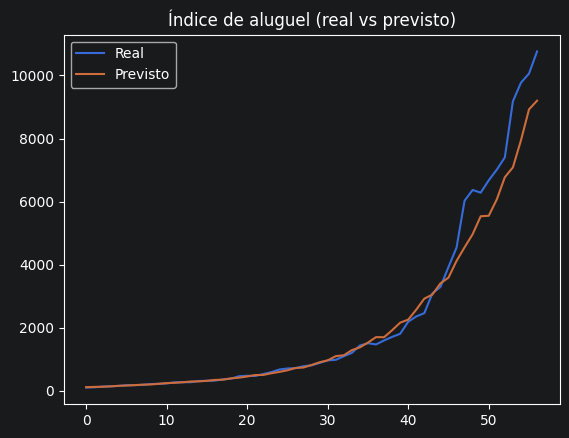

In [25]:
# suponha um valor inicial
base = 100

real_index = base * np.exp(y_test.cumsum())
pred_index = base * np.exp(pd.Series(y_pred).cumsum())

plt.figure()
plt.plot(real_index.values, label="Real")
plt.plot(pred_index.values, label="Previsto")
plt.legend()
plt.title("Índice de aluguel (real vs previsto)")
plt.show()

A inclusão de uma defasagem da variável dependente resultou em melhora significativa no desempenho preditivo do modelo, reduzindo o erro médio de aproximadamente 11,7 para 8,9 pontos percentuais.

Esse resultado indica a presença de persistência temporal nos preços de aluguel, sugerindo que a dinâmica do mercado apresenta inércia.

Métricas baseadas em erro percentual (MAPE) não foram utilizadas, devido à natureza da variável dependente, que pode assumir valores próximos de zero, gerando distorções.

Foram testadas diferentes especificações dinâmicas, incluindo a utilização de defasagens da variável dependente e médias móveis.

Os resultados indicam que a inclusão de uma defasagem simples (lag 1) apresenta melhor desempenho preditivo em comparação à média móvel, sugerindo que o mercado de aluguel responde mais fortemente a variações recentes do que a tendências suavizadas.

O modelo apresenta boa capacidade de replicar a tendência de crescimento dos aluguéis, ainda que com menor precisão em períodos de maior volatilidade.

In [26]:
# =========================
# 1. DADOS (mesmo split que você já usa)
# =========================
features = [
    "dlog_aluguel_lag1",
    "dlog_pop_lag1",
    "selic_media",
    "d_ic_br",
    "dlog_incc_lag1"
]

X_train = train[features]
y_train = train["dlog_aluguel"]

X_test = test[features]
y_test = test["dlog_aluguel"]

# =========================
# 2. FUNÇÃO OBJETIVO
# =========================
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 10, 1000),
        "max_depth": trial.suggest_int("max_depth", 0, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.02),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42
    }

    model = XGBRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)

    return mse

# =========================
# 3. RODAR OPTUNA
# =========================
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200)

# =========================
# 4. RESULTADOS
# =========================
print("Melhor MSE:", study.best_value)
print("Melhores parâmetros:")
print(study.best_params)

[I 2026-05-14 02:44:13,445] A new study created in memory with name: no-name-7ceae9de-7082-491f-81e0-d79e13740675
[I 2026-05-14 02:44:13,692] Trial 0 finished with value: 0.008268440291874348 and parameters: {'n_estimators': 327, 'max_depth': 1, 'learning_rate': 0.00886351482103874, 'subsample': 0.6276649714140323, 'colsample_bytree': 0.8839296654742164, 'gamma': 0.8247380564077608, 'reg_lambda': 0.6934687601684292}. Best is trial 0 with value: 0.008268440291874348.
[I 2026-05-14 02:44:13,755] Trial 1 finished with value: 0.00827096319503254 and parameters: {'n_estimators': 662, 'max_depth': 2, 'learning_rate': 0.0072531749778456025, 'subsample': 0.72209057426254, 'colsample_bytree': 0.8706803164467612, 'gamma': 0.7653032906047241, 'reg_lambda': 2.464771296129064}. Best is trial 0 with value: 0.008268440291874348.
[I 2026-05-14 02:44:13,822] Trial 2 finished with value: 0.008279794896744467 and parameters: {'n_estimators': 791, 'max_depth': 7, 'learning_rate': 0.010232504220883603, 'su

Melhor MSE: 0.008147765632413498
Melhores parâmetros:
{'n_estimators': 667, 'max_depth': 2, 'learning_rate': 0.018117224091468157, 'subsample': 0.6171099508207745, 'colsample_bytree': 0.6503525879825335, 'gamma': 0.2796694182653666, 'reg_lambda': 2.953870497121101}


In [27]:
best_model = XGBRegressor(**study.best_params)

best_model.fit(X_train, y_train)

y_pred_optuna = best_model.predict(X_test)

mse_optuna = mean_squared_error(y_test, y_pred_optuna)
pprint.pprint(study.best_params)
print("MSE XGBoost + Optuna:", mse_optuna)

{'colsample_bytree': 0.6503525879825335,
 'gamma': 0.2796694182653666,
 'learning_rate': 0.018117224091468157,
 'max_depth': 2,
 'n_estimators': 667,
 'reg_lambda': 2.953870497121101,
 'subsample': 0.6171099508207745}
MSE XGBoost + Optuna: 0.00824632514027561


In [28]:
print("OLS:", mse_ols)
print("XGBoost + Optuna:", mse_optuna)

OLS: 0.0016711648436757206
XGBoost + Optuna: 0.00824632514027561


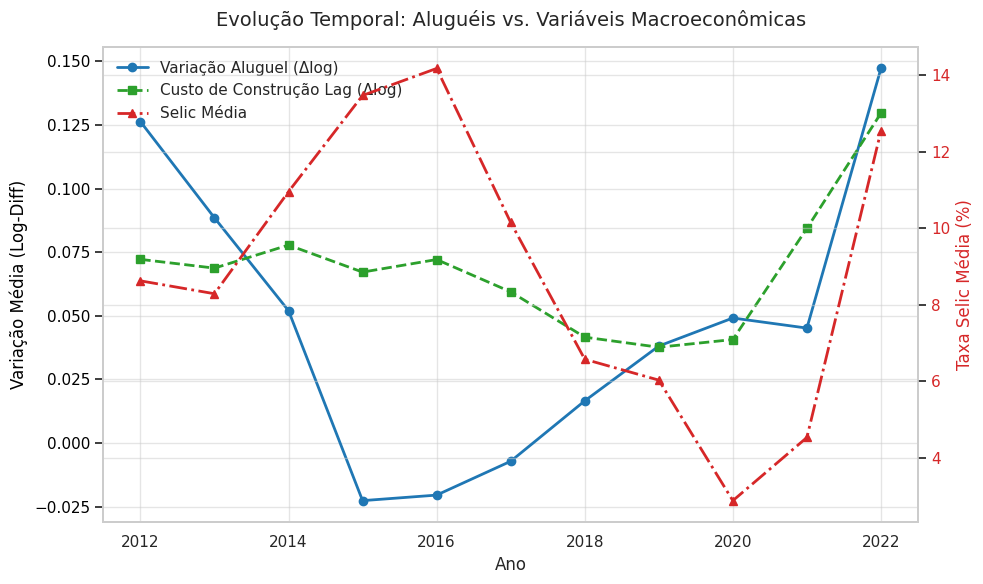

In [29]:
sns.set_theme(style="whitegrid")

df_ano = df_model.groupby('ano')[['dlog_aluguel', 'selic_media', 'dlog_incc_lag1']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = '#1f77b4' # Azul
color2 = '#2ca02c' # Verde
ax1.set_xlabel('Ano', fontsize=12)
ax1.set_ylabel('Variação Média (Log-Diff)', color='black', fontsize=12)
ax1.plot(df_ano['ano'], df_ano['dlog_aluguel'], marker='o', color=color1, label='Variação Aluguel (Δlog)', linewidth=2)
ax1.plot(df_ano['ano'], df_ano['dlog_incc_lag1'], marker='s', color=color2, linestyle='--', label='Custo de Construção Lag (Δlog)', linewidth=2)
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()
color3 = '#d62728' # Vermelho
ax2.set_ylabel('Taxa Selic Média (%)', color=color3, fontsize=12)
ax2.plot(df_ano['ano'], df_ano['selic_media'], marker='^', color=color3, linestyle='-.', label='Selic Média', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color3)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=False)

plt.title('Evolução Temporal: Aluguéis vs. Variáveis Macroeconômicas', fontsize=14, pad=15)
plt.tight_layout()

plt.savefig('../figures/grafico_serie_temporal_macro.pdf', format='pdf', bbox_inches='tight')
plt.show()

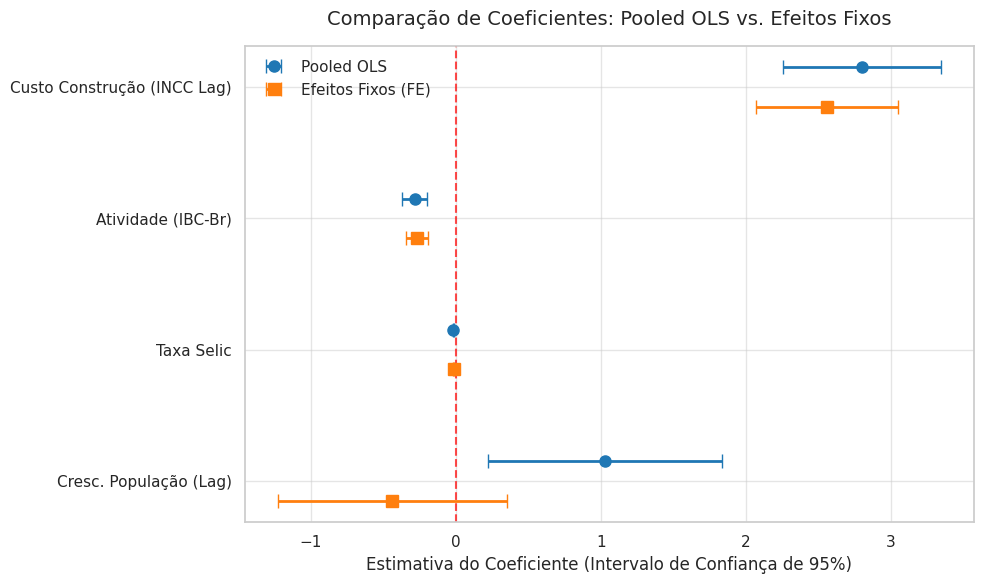

In [35]:
import numpy as np
import matplotlib.pyplot as plt

params_ols = model_sm.params.drop('const')
conf_ols = model_sm.conf_int().drop('const')
err_ols = params_ols - conf_ols[0]

params_fe = result_fe.params.drop('const', errors='ignore')
conf_fe = result_fe.conf_int().drop('const', errors='ignore')
err_fe = params_fe - conf_fe['lower']

nomes_variaveis = {
    'dlog_pop_lag1': 'Cresc. População (Lag)',
    'selic_media': 'Taxa Selic',
    'd_ic_br': 'Atividade (IBC-Br)',
    'dlog_incc_lag1': 'Custo Construção (INCC Lag)'
}

y_pos = np.arange(len(params_ols))
height = 0.3

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(params_ols.values, y_pos + height/2, xerr=err_ols.values, fmt='o',
            color='#1f77b4', label='Pooled OLS', capsize=5, elinewidth=2, markersize=8)

ax.errorbar(params_fe.values, y_pos - height/2, xerr=err_fe.values, fmt='s',
            color='#ff7f0e', label='Efeitos Fixos (FE)', capsize=5, elinewidth=2, markersize=8)

ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels([nomes_variaveis[v] for v in params_ols.index], fontsize=11)
ax.set_xlabel('Estimativa do Coeficiente (Intervalo de Confiança de 95%)', fontsize=12)
ax.set_title('Comparação de Coeficientes: Pooled OLS vs. Efeitos Fixos', fontsize=14, pad=15)
ax.legend(frameon=False, fontsize=11)

plt.tight_layout()

# Salvar em PDF para o LaTeX
plt.savefig('../figures/grafico_forest_plot.pdf', format='pdf', bbox_inches='tight')
plt.show()

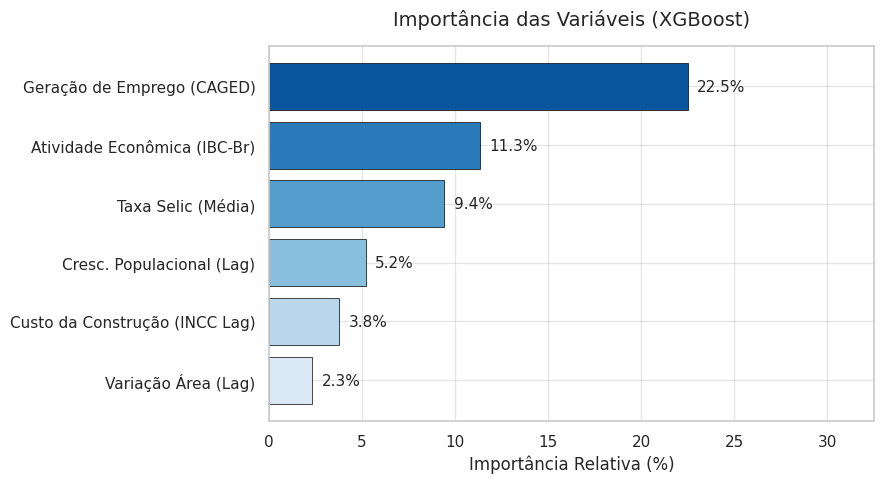

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

nomes_ml = {
    'dlog_incc_lag1': 'Custo da Construção (INCC Lag)',
    'selic_media': 'Taxa Selic (Média)',
    'd_ic_br': 'Atividade Econômica (IBC-Br)',
    'dlog_pop_lag1': 'Cresc. Populacional (Lag)',
    'caged_per_capita': 'Geração de Emprego (CAGED)',
    'dlog_area_lag1': 'Variação Área (Lag)',
    'dlog_aluguel_lag1': 'Aluguel (Autorregressão)' # Adicionado caso a defasagem esteja na memória
}

importance_plot = importance[importance.index.isin(nomes_ml.keys())].copy()

importance_plot = importance_plot.sort_values(ascending=True)

importance_plot.index = importance_plot.index.map(nomes_ml)

fig, ax = plt.subplots(figsize=(9, 5))
cores = sns.color_palette("Blues", len(importance_plot))

ax.barh(importance_plot.index, importance_plot.values * 100, color=cores, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Importância Relativa (%)', fontsize=12)
ax.set_title('Importância das Variáveis (XGBoost)', fontsize=14, pad=15)

for i, v in enumerate(importance_plot.values):
    ax.text(v * 100 + 0.5, i, f"{v * 100:.1f}%", va='center', fontsize=11)

ax.set_xlim(0, max(importance_plot.values * 100) + 10)

plt.tight_layout()

plt.savefig('../figures/grafico_feature_importance.pdf', format='pdf', bbox_inches='tight')
plt.show()

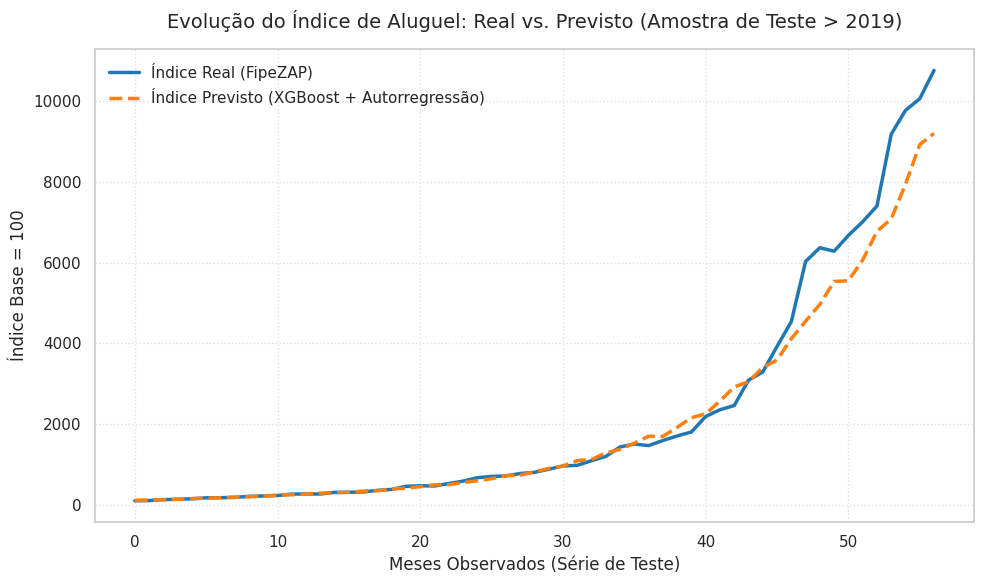

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(real_index.values, label="Índice Real (FipeZAP)", color='#1f77b4', linewidth=2.5)
ax.plot(pred_index.values, label="Índice Previsto (XGBoost + Autorregressão)", color='#ff7f0e', linewidth=2.5, linestyle='--')

ax.set_title("Evolução do Índice de Aluguel: Real vs. Previsto (Amostra de Teste > 2019)", fontsize=14, pad=15)
ax.set_xlabel("Meses Observados (Série de Teste)", fontsize=12)
ax.set_ylabel("Índice Base = 100", fontsize=12)

ax.grid(True, linestyle=':', alpha=0.6)

ax.legend(frameon=False, loc='upper left', fontsize=11)

plt.tight_layout()

plt.savefig('../figures/grafico_previsao_aluguel.pdf', format='pdf', bbox_inches='tight')
plt.show()